# EDA — Predição de Alfabetização

Tech Challenge Fase 3 · Notebook 01

Esta análise não é descritiva por obrigação: cada seção existe para **decidir alguma coisa
na modelagem**. Ao final, a seção 9 consolida as decisões que a EDA sustenta.

A pergunta de fundo é: *quais alunos avaliados em 2024 têm risco de não estarem
alfabetizados, usando apenas informação disponível antes da avaliação?*

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

RAW = Path("../data/raw")
IMG = Path("../images")
IMG.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

CORTE = 743  # ponto de corte do Indicador Criança Alfabetizada na escala Saeb

alunos = pd.read_parquet(RAW / "alunos.parquet")
print(f"{len(alunos):,} linhas x {alunos.shape[1]} colunas")
alunos.head()

3,867,999 linhas x 10 colunas


,ano,id_municipio,id_escola,rede,caderno,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno
0,2023,2211001,60006431,3,1,0,0,0,NaN,NaN
1,2023,4205407,60034824,2,1,0,0,0,NaN,NaN
2,2023,4301602,60039942,3,1,0,0,0,NaN,NaN
3,2024,1302603,60000925,2,1,0,0,0,NaN,NaN
4,2024,1502152,60003041,3,1,0,0,0,NaN,NaN


## 1. O alvo e os dois vazamentos

Antes de qualquer distribuição, precisamos saber **o que não pode entrar no modelo**.
Duas colunas parecem features e não são.

### 1.1 `proficiencia` é o alvo antes do corte

O Indicador Criança Alfabetizada é definido como proficiência ≥ 743 na escala Saeb. Se isso
for exato, `proficiencia` não é uma variável explicativa — é o próprio rótulo sem o `if`.

In [2]:
avaliados = alunos[(alunos.presenca == "1") & (alunos.preenchimento_caderno == "1")].copy()
avaliados["alfab"] = (avaliados.alfabetizado == "1").astype(int)

regra = (avaliados.proficiencia >= CORTE).astype(int)
aderencia = (regra == avaliados.alfab).mean()

print(f"Alunos avaliados: {len(avaliados):,}")
print(f"alfabetizado == (proficiencia >= {CORTE}) em {aderencia*100:.4f}% dos casos")
print(f"Violações: {(regra != avaliados.alfab).sum()}")

Alunos avaliados: 3,354,661
alfabetizado == (proficiencia >= 743) em 100.0000% dos casos
Violações: 0


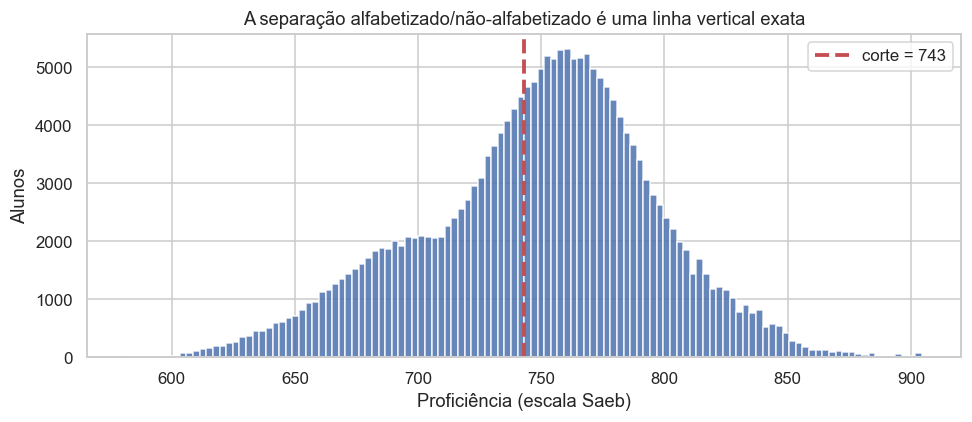

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
amostra = avaliados.proficiencia.sample(200_000, random_state=42)
ax.hist(amostra, bins=120, color="#4C72B0", alpha=.85)
ax.axvline(CORTE, color="#C44E52", lw=2.5, ls="--", label=f"corte = {CORTE}")
ax.set_xlabel("Proficiência (escala Saeb)")
ax.set_ylabel("Alunos")
ax.set_title("A separação alfabetizado/não-alfabetizado é uma linha vertical exata")
ax.legend()
plt.tight_layout()
plt.savefig(IMG / "01_corte_proficiencia.png", bbox_inches="tight")
plt.show()

> **Decisão:** `proficiencia` é descartada. Um modelo que a recebesse apenas reaprenderia
> o limiar e reportaria acurácia ~100% — métrica inflada, valor zero.

### 1.2 Aluno ausente é sempre "não alfabetizado"

`presenca` e `preenchimento_caderno` parecem candidatas inofensivas. Não são.

In [4]:
tab = (alunos
       .groupby(["presenca", "preenchimento_caderno", "alfabetizado"])
       .agg(alunos=("ano", "size"), profic_media=("proficiencia", "mean"))
       .reset_index())
print(tab.to_string(index=False))

ausentes = alunos[alunos.presenca == "0"]
print(f"\nAusentes: {len(ausentes):,}")
print(f"  todos com alfabetizado=0? {(ausentes.alfabetizado == '0').all()}")
print(f"  todos com proficiência nula? {ausentes.proficiencia.isna().all()}")

presenca preenchimento_caderno alfabetizado  alunos  profic_media
       0                     0            0  512153           NaN
       1                     0            0    1185           NaN
       1                     1            0 1370115    702.815497
       1                     1            1 1984546    779.837129

Ausentes: 512,153
  todos com alfabetizado=0? True
  todos com proficiência nula? True


> **Decisão:** ausência é codificação administrativa, não medição — a criança não foi
> avaliada, então não sabemos se está alfabetizada. `presenca` e `preenchimento_caderno`
> viram **filtro** (definem o universo), nunca feature. Sem esse filtro, o modelo aprenderia
> "quem faltou não é alfabetizado", que é verdadeiro na base e falso no mundo.

## 2. Universo de modelagem e balanceamento

In [5]:
print(f"Base bruta:            {len(alunos):,}")
print(f"Após filtro de validade: {len(avaliados):,}  ({len(avaliados)/len(alunos)*100:.1f}%)")
print(f"\nTaxa de alfabetização: {avaliados.alfab.mean()*100:.1f}%")

resumo = (avaliados.groupby("ano")
          .agg(alunos=("alfab", "size"),
               municipios=("id_municipio", "nunique"),
               escolas=("id_escola", "nunique"),
               taxa=("alfab", "mean")))
resumo["taxa"] = (resumo.taxa * 100).round(1)
print()
print(resumo.to_string())

Base bruta:            3,867,999
Após filtro de validade: 3,354,661  (86.7%)

Taxa de alfabetização: 59.2%



       alunos  municipios  escolas  taxa
ano                                     
2023  1502809        4871    36525  58.4
2024  1851852        5517    42328  59.8


> **Decisão:** alvo praticamente balanceado (59/41). Não há necessidade de `class_weight`,
> SMOTE ou ajuste de threshold por desbalanceamento — e acurácia, embora não seja a melhor
> métrica, ao menos não é enganosa aqui. Ainda assim reportaremos F1 e AUC-PR, porque o
> custo de errar não é simétrico (ver seção 9).

## 3. Onde está a desigualdade: rede, UF e região

In [6]:
UF_POR_CODIGO = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA", "16": "AP", "17": "TO",
    "21": "MA", "22": "PI", "23": "CE", "24": "RN", "25": "PB", "26": "PE", "27": "AL",
    "28": "SE", "29": "BA", "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS", "50": "MS", "51": "MT", "52": "GO", "53": "DF",
}
REGIAO_POR_DIGITO = {"1": "Norte", "2": "Nordeste", "3": "Sudeste", "4": "Sul", "5": "Centro-Oeste"}
REDE_NOME = {"2": "Estadual", "3": "Municipal", "4": "Privada"}

avaliados["uf"] = avaliados.id_municipio.str[:2].map(UF_POR_CODIGO)
avaliados["regiao"] = avaliados.id_municipio.str[:1].map(REGIAO_POR_DIGITO)
avaliados["rede_nome"] = avaliados.rede.map(REDE_NOME)

print(avaliados.groupby(["ano", "rede_nome"])
      .agg(alunos=("alfab", "size"), taxa=("alfab", "mean"))
      .assign(taxa=lambda d: (d.taxa * 100).round(1))
      .to_string())

                 alunos  taxa
ano  rede_nome               
2023 Estadual    131522  61.3
     Municipal  1371287  58.1
2024 Estadual    241074  62.5
     Municipal  1610754  59.4
     Privada         24  66.7


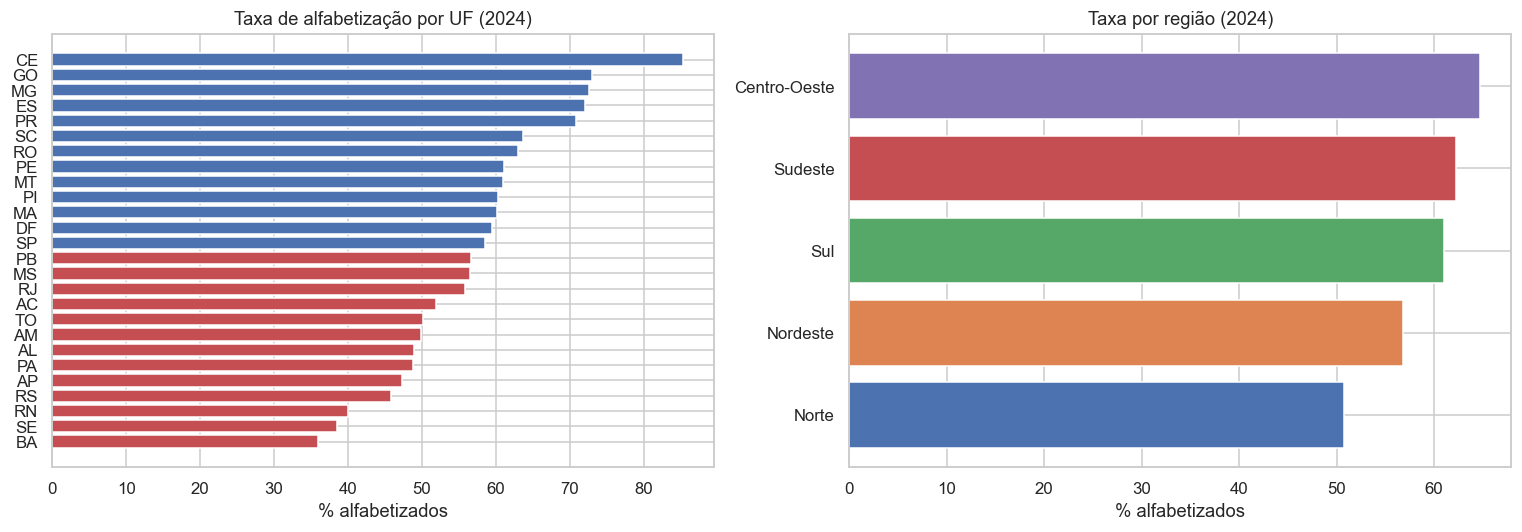

Amplitude entre UFs: 36.0% a 85.3% (49.4 p.p. de diferença)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

por_uf = (avaliados[avaliados.ano == 2024].groupby("uf")
          .agg(taxa=("alfab", "mean"), n=("alfab", "size"))
          .sort_values("taxa"))
cores = [sns.color_palette("deep")[0] if t >= por_uf.taxa.median() else "#C44E52"
         for t in por_uf.taxa]
axes[0].barh(por_uf.index, por_uf.taxa * 100, color=cores)
axes[0].set_xlabel("% alfabetizados")
axes[0].set_title("Taxa de alfabetização por UF (2024)")

por_reg = (avaliados[avaliados.ano == 2024].groupby("regiao")
           .agg(taxa=("alfab", "mean")).sort_values("taxa"))
axes[1].barh(por_reg.index, por_reg.taxa * 100, color=sns.color_palette("deep"))
axes[1].set_xlabel("% alfabetizados")
axes[1].set_title("Taxa por região (2024)")

plt.tight_layout()
plt.savefig(IMG / "02_taxa_por_uf_regiao.png", bbox_inches="tight")
plt.show()

print(f"Amplitude entre UFs: {por_uf.taxa.min()*100:.1f}% a {por_uf.taxa.max()*100:.1f}% "
      f"({(por_uf.taxa.max()-por_uf.taxa.min())*100:.1f} p.p. de diferença)")

> **Hipótese H1:** existe forte gradiente territorial. Variáveis de UF/região e o contexto
> socioeconômico do município devem carregar sinal relevante — testado na seção 6.

## 4. Quanto do resultado é "escola"?

Se alunos da mesma escola tendem a ter o mesmo destino, a escola é a unidade de intervenção
natural. Medimos isso decompondo a variância.

In [8]:
a24 = avaliados[avaliados.ano == 2024]

escolas = a24.groupby("id_escola")["alfab"].agg(taxa="mean", n="size")
escolas = escolas[escolas.n >= 20]  # amostra mínima para a taxa ser estável

var_total = a24.alfab.var()
var_entre = escolas.taxa.var()

print(f"Escolas com ≥20 avaliados: {len(escolas):,}")
print(f"Variância total (aluno):          {var_total:.4f}")
print(f"Variância entre escolas:          {var_entre:.4f}")
print(f"→ {var_entre/var_total*100:.1f}% da variância fica ENTRE escolas")
print(f"\nTaxa por escola: p10={escolas.taxa.quantile(.10)*100:.0f}%  "
      f"mediana={escolas.taxa.median()*100:.0f}%  p90={escolas.taxa.quantile(.90)*100:.0f}%")

Escolas com ≥20 avaliados: 31,469
Variância total (aluno):          0.2404
Variância entre escolas:          0.0426
→ 17.7% da variância fica ENTRE escolas

Taxa por escola: p10=32%  mediana=60%  p90=87%


In [9]:
# Escolas do mesmo município divergem entre si?
esc_mun = (a24.groupby(["id_municipio", "id_escola"])["alfab"]
           .agg(taxa="mean", n="size").reset_index())
esc_mun = esc_mun[esc_mun.n >= 20]
disp = esc_mun.groupby("id_municipio")["taxa"].agg(desvio="std", escolas="count")
disp = disp[disp.escolas >= 5]

print(f"Municípios com ≥5 escolas elegíveis: {len(disp):,}")
print(f"Desvio-padrão das taxas entre escolas do MESMO município:")
print(f"  média={disp.desvio.mean()*100:.1f} p.p. | mediana={disp.desvio.median()*100:.1f} p.p. "
      f"| p90={disp.desvio.quantile(.90)*100:.1f} p.p.")

Municípios com ≥5 escolas elegíveis: 1,436
Desvio-padrão das taxas entre escolas do MESMO município:
  média=13.4 p.p. | mediana=13.2 p.p. | p90=19.6 p.p.


**17,7% da variância entre escolas** e **~13 p.p. de dispersão dentro do mesmo município**:
a escola importa, e importa *além* do município. O passo seguinte seria óbvio — usar o
histórico da escola como feature. A seção 5 mostra por que isso é impossível.

## 5. 🔍 O achado central: `id_escola` não é rastreável entre anos

Para usar o desempenho de 2023 como feature de 2024, o identificador da escola precisa
apontar para a mesma escola nos dois anos. O schema avisa que o código é *"máscara do código
da escola (códigos fictícios)"* — então isso precisa ser verificado, não assumido.

**Teste decisivo:** para um mesmo `id_escola` presente nos dois anos, o município bate?
Escolas não mudam de município — se o ID fosse estável, a taxa seria ~100%.

In [10]:
v = avaliados
v_uf = v.assign(uf_cod=v.id_municipio.str[:2])

mun_por_ano = v.groupby(["id_escola", "ano"])["id_municipio"].first().unstack().dropna()
uf_por_ano = v_uf.groupby(["id_escola", "ano"])["uf_cod"].first().unstack().dropna()

# Baseline: coincidência esperada se o ID fosse sorteado ao acaso
esc24 = v_uf[v_uf.ano == 2024].groupby("id_escola").agg(
    mun=("id_municipio", "first"), uf=("uf_cod", "first"))
esperado_mun = (esc24.mun.value_counts(normalize=True) ** 2).sum()
esperado_uf = (esc24.uf.value_counts(normalize=True) ** 2).sum()

obs_mun = (mun_por_ano[2023] == mun_por_ano[2024]).mean()
obs_uf = (uf_por_ano[2023] == uf_por_ano[2024]).mean()

print(f"id_escola presentes nos dois anos: {len(mun_por_ano):,}\n")
print(f"{'nível':12s} {'observado':>11s} {'ao acaso':>11s} {'se estável':>11s}")
print("-" * 48)
print(f"{'município':12s} {obs_mun*100:10.2f}% {esperado_mun*100:10.2f}% {'~100%':>11s}")
print(f"{'UF':12s} {obs_uf*100:10.2f}% {esperado_uf*100:10.2f}% {'~100%':>11s}")

id_escola presentes nos dois anos: 36,051

nível          observado    ao acaso  se estável
------------------------------------------------
município          2.40%       0.18%       ~100%
UF                80.63%       6.63%       ~100%


O município coincide em **2,4%** dos casos — ou seja, **97,6% dos "pares" entre anos são
escolas diferentes**. A UF coincide em 80%, o que revela a mecânica da máscara: os códigos
são alocados em blocos por estado, mas embaralhados dentro do estado a cada ano.

Confirmação independente: se o ID fosse estável, a taxa da escola em 2023 deveria prever a
de 2024.

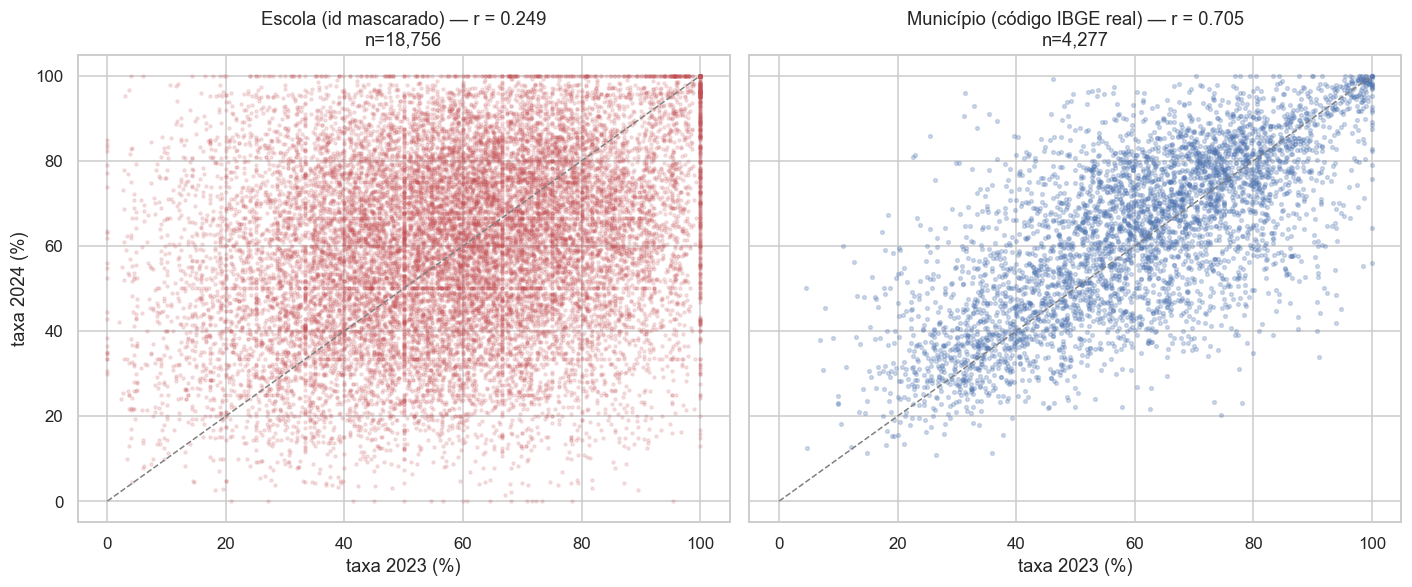

In [11]:
esc = v.groupby(["id_escola", "ano"])["alfab"].agg(["mean", "size"]).unstack()
esc_ok = esc[(esc[("size", 2023)] >= 20) & (esc[("size", 2024)] >= 20)]

mun = v.groupby(["id_municipio", "ano"])["alfab"].agg(["mean", "size"]).unstack()
mun_ok = mun[(mun[("size", 2023)] >= 30) & (mun[("size", 2024)] >= 30)]

r_esc = np.corrcoef(esc_ok[("mean", 2023)], esc_ok[("mean", 2024)])[0, 1]
r_mun = np.corrcoef(mun_ok[("mean", 2023)], mun_ok[("mean", 2024)])[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
axes[0].scatter(esc_ok[("mean", 2023)]*100, esc_ok[("mean", 2024)]*100, s=4, alpha=.15, color="#C44E52")
axes[0].set_title(f"Escola (id mascarado) — r = {r_esc:.3f}\nn={len(esc_ok):,}")
axes[1].scatter(mun_ok[("mean", 2023)]*100, mun_ok[("mean", 2024)]*100, s=6, alpha=.25, color="#4C72B0")
axes[1].set_title(f"Município (código IBGE real) — r = {r_mun:.3f}\nn={len(mun_ok):,}")
for ax in axes:
    ax.plot([0, 100], [0, 100], ls="--", c="gray", lw=1)
    ax.set_xlabel("taxa 2023 (%)")
axes[0].set_ylabel("taxa 2024 (%)")
plt.tight_layout()
plt.savefig(IMG / "03_estabilidade_id.png", bbox_inches="tight")
plt.show()

> **Decisão (muda o desenho do projeto):** nenhuma feature histórica por escola é viável.
> O sinal que a seção 4 mostrou existir dentro de cada ano é **real, mas inalcançável entre
> anos**. A modelagem fica restrita a features de **município**, que usa código IBGE real e
> persistente (r = 0,70).
>
> Essa também é uma **recomendação de política pública**: publicar um identificador de escola
> pseudonimizado porém estável entre anos — sem expor a identidade da escola — habilitaria
> monitoramento longitudinal e modelos de risco muito mais precisos.

## 6. Enriquecimento: cobertura e sinal

Com a escola fora, as features municipais passam a carregar todo o peso. Elas cobrem a base?
E correlacionam com o resultado?

In [12]:
idhm = pd.read_parquet(RAW / "idhm_municipio.parquet")
pib = pd.read_parquet(RAW / "pib_populacao_municipio.parquet")
censo = pd.read_parquet(RAW / "censo_escolar_municipio.parquet")
pib["pib_per_capita"] = pib.pib / pib.populacao

for nome, df in [("IDHM (censo 2010)", idhm), ("PIB + população (2023)", pib),
                 ("Censo Escolar (2023)", censo)]:
    cobertura = a24.id_municipio.isin(set(df.id_municipio)).mean()
    print(f"{nome:26s} {len(df):>6,} municípios | cobre {cobertura*100:5.1f}% dos alunos de 2024")

IDHM (censo 2010)           5,565 municípios | cobre 100.0% dos alunos de 2024
PIB + população (2023)      5,570 municípios | cobre 100.0% dos alunos de 2024
Censo Escolar (2023)        5,570 municípios | cobre 100.0% dos alunos de 2024


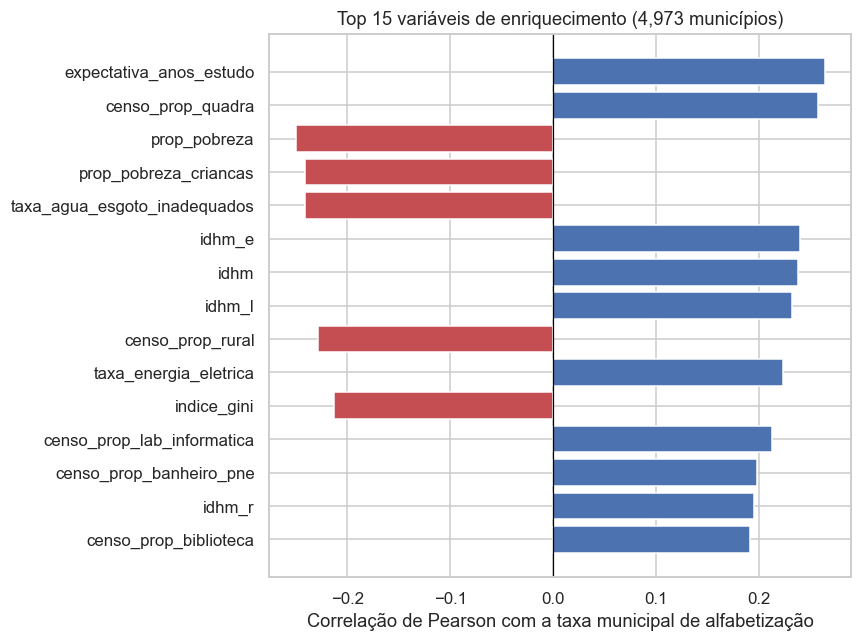

expectativa_anos_estudo         0.264
censo_prop_quadra               0.257
prop_pobreza                   -0.250
prop_pobreza_criancas          -0.242
taxa_agua_esgoto_inadequados   -0.241
idhm_e                          0.240
idhm                            0.238
idhm_l                          0.232
censo_prop_rural               -0.229
taxa_energia_eletrica           0.223
indice_gini                    -0.213
censo_prop_lab_informatica      0.212
censo_prop_banheiro_pne         0.197
idhm_r                          0.195
censo_prop_biblioteca           0.191


In [13]:
taxa_mun = (a24.groupby("id_municipio")["alfab"]
            .agg(taxa="mean", n="size").reset_index())
taxa_mun = taxa_mun[taxa_mun.n >= 30]   # municípios com amostra suficiente

painel = (taxa_mun
          .merge(idhm, on="id_municipio", how="left")
          .merge(censo, on="id_municipio", how="left")
          .merge(pib[["id_municipio", "pib_per_capita", "populacao"]], on="id_municipio", how="left"))

num = painel.select_dtypes(include=[np.number]).drop(columns=["n"])
cor = num.corr()["taxa"].drop("taxa").sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
cores = ["#4C72B0" if c > 0 else "#C44E52" for c in cor.values]
ax.barh(range(len(cor)), cor.values, color=cores)
ax.set_yticks(range(len(cor)))
ax.set_yticklabels(cor.index)
ax.invert_yaxis()
ax.axvline(0, color="black", lw=.8)
ax.set_xlabel("Correlação de Pearson com a taxa municipal de alfabetização")
ax.set_title(f"Top 15 variáveis de enriquecimento ({len(painel):,} municípios)")
plt.tight_layout()
plt.savefig(IMG / "04_correlacao_enriquecimento.png", bbox_inches="tight")
plt.show()

print(cor.round(3).to_string())

> **Hipótese H2 confirmada parcialmente:** as correlações são consistentes em sinal e fazem
> sentido teórico (escolaridade adulta e IDHM educacional sobem, pobreza e saneamento
> inadequado descem), mas todas são **moderadas** (|r| ≤ 0,27). Nenhuma variável isolada
> resolve o problema — o modelo precisará combiná-las.
>
> **Decisão:** manter as três fontes. A cobertura é praticamente total (≈100% dos alunos),
> então não haverá imputação massiva por falta de join.

## 7. Teto de performance: o que dá para esperar

Antes de treinar qualquer modelo, vale medir o que a informação disponível permite. Usamos a
regra mais simples possível — "a taxa do município no ano anterior" — como referência.

In [14]:
h23 = avaliados[avaliados.ano == 2023]

mun23 = h23.groupby("id_municipio")["alfab"].agg(taxa_mun_2023="mean", n_mun_2023="size")
esc23 = h23.groupby("id_escola")["alfab"].agg(taxa_esc_2023="mean")

teste = (a24.merge(mun23, on="id_municipio", how="left")
            .merge(esc23, on="id_escola", how="left"))

media_global = h23.alfab.mean()
pred_mun = teste.taxa_mun_2023.fillna(media_global)
pred_esc = teste.taxa_esc_2023.fillna(teste.taxa_mun_2023).fillna(media_global)

print(f"AUC — taxa do MUNICÍPIO em 2023 : {roc_auc_score(teste.alfab, pred_mun):.4f}")
print(f"AUC — taxa da ESCOLA em 2023    : {roc_auc_score(teste.alfab, pred_esc):.4f}  ← pior, por ser ~98% ruído")
print(f"\nCobertura do histórico municipal: {teste.taxa_mun_2023.notna().mean()*100:.1f}% dos alunos de 2024")
print(f"Cobertura do histórico de escola: {teste.taxa_esc_2023.notna().mean()*100:.1f}% (mas inútil)")

AUC — taxa do MUNICÍPIO em 2023 : 0.6280


AUC — taxa da ESCOLA em 2023    : 0.5521  ← pior, por ser ~98% ruído

Cobertura do histórico municipal: 76.9% dos alunos de 2024
Cobertura do histórico de escola: 79.0% (mas inútil)


> **Referência estabelecida:** AUC ≈ **0,63** com uma única variável. Esse é o piso que o
> modelo precisa superar, e dá a ordem de grandeza do que é alcançável — não se deve esperar
> AUC 0,90 quando não existe nenhum atributo individual da criança na base.
>
> **Decisão:** o baseline da Fase 4 será exatamente isso (taxa municipal de 2023), além do
> `DummyClassifier`. Qualquer ganho da modelagem é medido contra essa régua.

## 8. Cold start: municípios sem histórico

In [15]:
teste["tem_hist_mun"] = teste.taxa_mun_2023.notna()
print(teste.groupby("tem_hist_mun")
      .agg(alunos=("alfab", "size"), taxa=("alfab", "mean"))
      .assign(taxa=lambda d: (d.taxa*100).round(1))
      .to_string())

sem = teste[~teste.tem_hist_mun]
print(f"\nAlunos sem histórico municipal: {len(sem):,} ({len(sem)/len(teste)*100:.1f}%)")
print(f"Municípios afetados: {sem.id_municipio.nunique():,}")

               alunos  taxa
tem_hist_mun               
False          428119  58.5
True          1423733  60.2

Alunos sem histórico municipal: 428,119 (23.1%)
Municípios afetados: 676


> **Decisão:** criar a flag `sem_historico_municipal` e **avaliar o modelo separadamente
> nesse subgrupo**. São justamente os municípios que entraram na avaliação agora — do ponto
> de vista de política pública, são os que mais precisam de triagem, e é onde o modelo
> depende inteiramente do contexto socioeconômico.

## 9. Decisões que esta EDA sustenta

| # | Decisão | Evidência |
|---|---|---|
| 1 | Descartar `proficiencia` | `alfabetizado == (proficiencia ≥ 743)` em 100,0000% dos casos (§1.1) |
| 2 | `presenca`/`preenchimento` viram filtro, não feature | 100% dos ausentes têm `alfabetizado=0` por codificação administrativa (§1.2) |
| 3 | Sem tratamento de desbalanceamento | Alvo em 59/41 (§2) |
| 4 | **Nenhuma feature histórica por escola** | `id_escola` re-sorteado anualmente: município coincide em 2,4% (§5) |
| 5 | Features municipais como base do modelo | Código IBGE é estável: r = 0,70 entre anos (§5) |
| 6 | Manter as 3 fontes de enriquecimento | Cobertura ≈100%, correlações coerentes mas moderadas (§6) |
| 7 | Baseline = taxa municipal de 2023 | AUC 0,63 com uma variável (§7) |
| 8 | `GroupKFold` por município | Alunos do mesmo município compartilham todas as features; split aleatório vazaria (§5, §7) |
| 9 | Flag + avaliação separada de cold start | Municípios sem histórico têm perfil distinto (§8) |
| 10 | Reportar F1 e AUC-PR além de acurácia | O custo de não sinalizar uma criança em risco é maior que o de sinalizar a mais (§9) |

### Limitações que vão para o README

- **Sem atributos individuais.** Os microdados são anonimizados sob LGPD: não há sexo,
  raça/cor, idade ou renda familiar. Todo o sinal é contextual.
- **`id_escola` não rastreável.** Impede o nível de análise mais informativo (§4 mostra que
  17,7% da variância está entre escolas).
- **IDHM de 2010.** O Atlas só publica em anos censitários; há 14 anos de defasagem,
  parcialmente compensada por PIB e população de 2023.
- **Apenas dois ciclos (2023, 2024).** Não há série longa o suficiente para tendência por
  município — só um "ano anterior".